In [1]:
from glob import glob

file_path = r'C:\git_test\01_tuteur guide\pandsa\data\*.csv'
files = glob(file_path)
files = files[3:-1]

In [2]:
import pandas as pd
df = pd.read_csv(files[0])

# 불필요한 컬럼 제거 - 의미가 중복된 데이터는 제거하는게 좋다
df.columns.unique()

Index(['상가업소번호', '상호명', '지점명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드',
       '상권업종중분류명', '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드',
       '시도명', '시군구코드', '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드',
       '대지구분코드', '대지구분명', '지번본번지', '지번부번지', '지번주소', '도로명코드', '도로명', '건물본번지',
       '건물부번지', '건물관리번호', '건물명', '도로명주소', '구우편번호', '신우편번호', '동정보', '층정보',
       '호정보', '경도', '위도'],
      dtype='object')

In [3]:
new_cols = ['상호명', '지점명', '상권업종대분류명', '상권업종중분류명', '상권업종소분류명', '시도명', '시군구명', '행정동명', '법정동명', '도로명주소', '경도', '위도']

shop = df[new_cols]

In [4]:
# 결측치 확인

shop.isna().sum()

상호명              0
지점명         100730
상권업종대분류명         0
상권업종중분류명         0
상권업종소분류명         0
시도명              0
시군구명             0
행정동명             0
법정동명             0
도로명주소            0
경도               0
위도               0
dtype: int64

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

<Axes: >

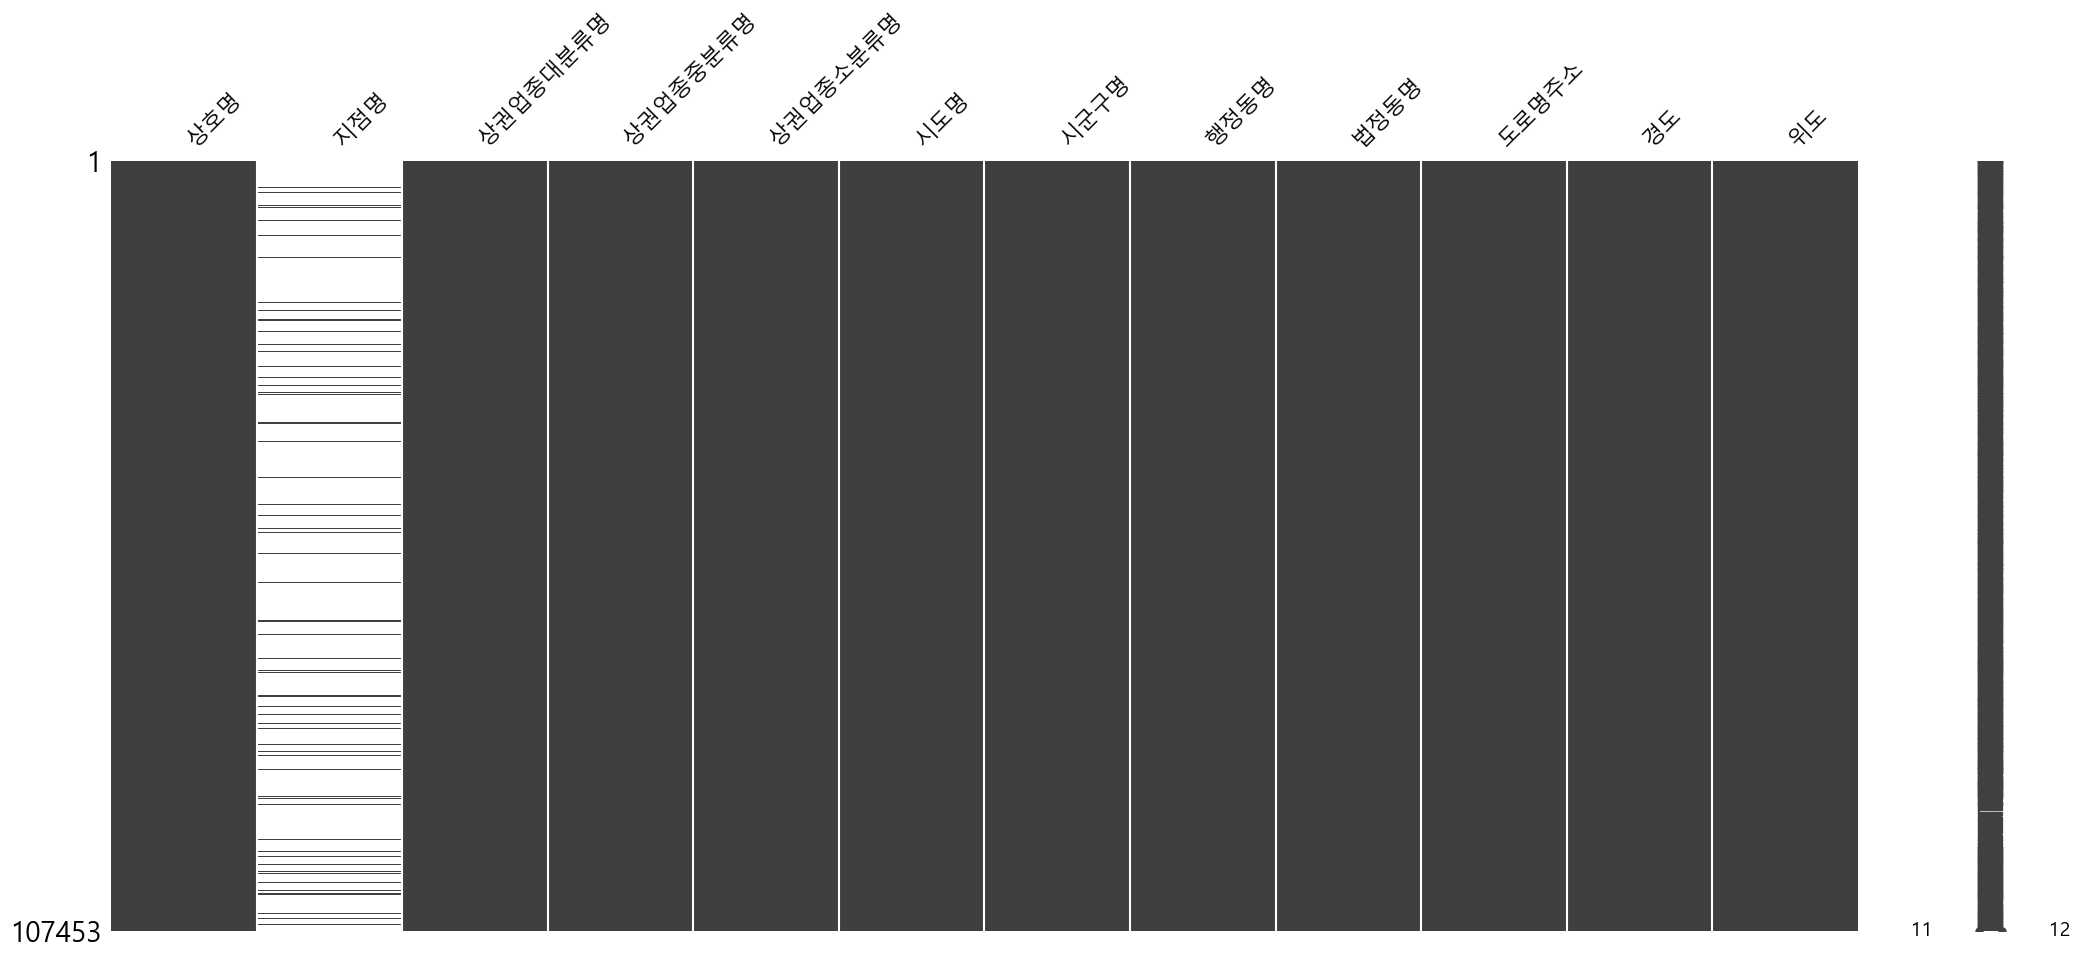

In [6]:
# 결측치 시각화

import missingno as msno
msno.matrix(shop)

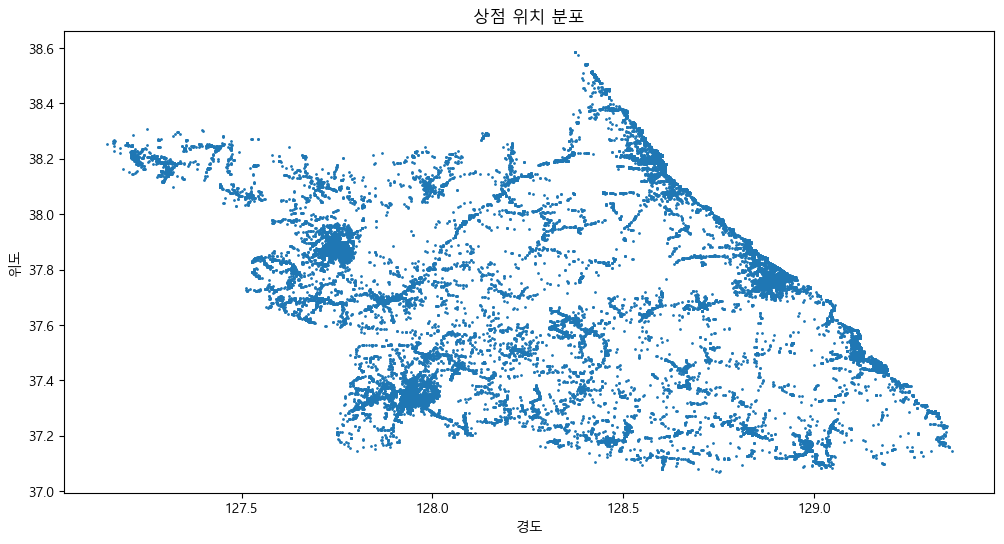

In [7]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(shop['경도'], shop['위도'], 'o', markersize=1)
plt.xlabel('경도')
plt.ylabel('위도')
plt.title('상점 위치 분포')
plt.show()

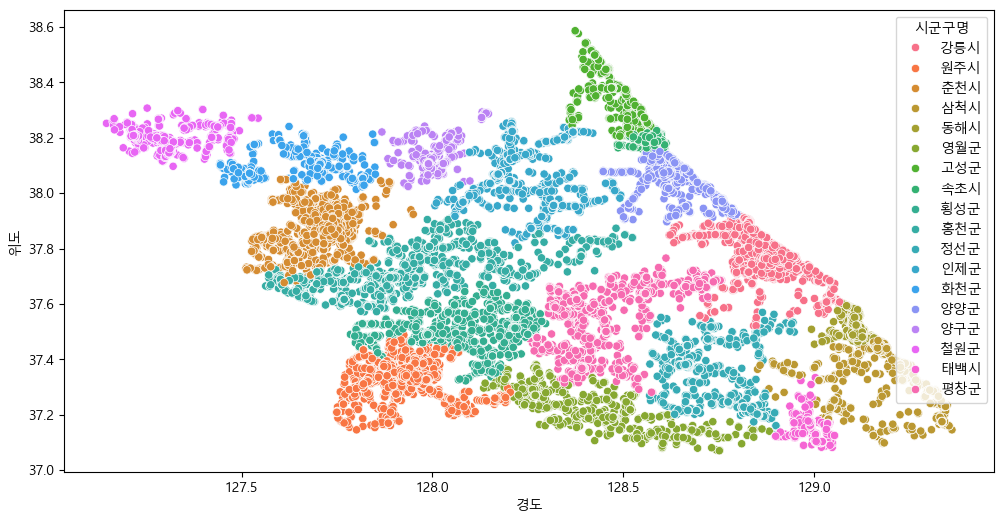

In [8]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12,6))
sns.scatterplot(data=shop,x='경도',y='위도',hue='시군구명',ax=ax)
plt.show()

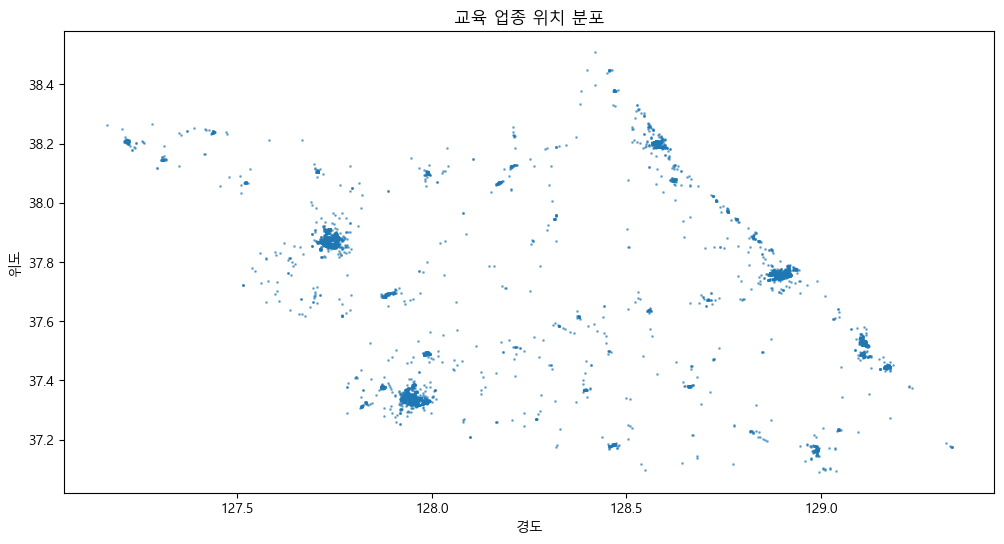

In [9]:
# 상권업종 대분류명이 교육과 관련된 정보 
edu = shop[shop['상권업종대분류명'] == '교육']

fig, ax = plt.subplots(figsize=(12,6))
plt.scatter(edu['경도'], edu['위도'], s=1, alpha=0.5)
plt.title('교육 업종 위치 분포')
plt.xlabel('경도')
plt.ylabel('위도')
plt.show()

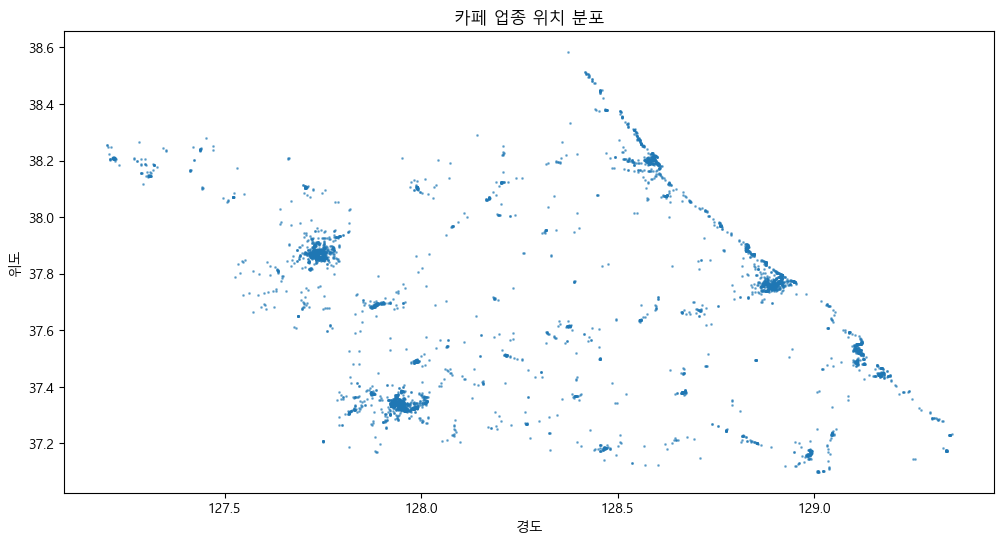

In [10]:
import matplotlib.pyplot as plt

cafe = shop[shop['상권업종소분류명'] == '카페']
fig, ax = plt.subplots(figsize=(12,6))
plt.scatter(cafe['경도'], cafe['위도'], s=1, alpha=0.5)
plt.title('카페 업종 위치 분포')
plt.xlabel('경도')
plt.ylabel('위도')
plt.show()

In [11]:

# 반경 200m 내 점포수
# 동일 업종수
# 경쟁 강도(같은 업종 density)

# step1 결측치 제거
# step2 공간 Feature 생성  KDTree
# step3 모델 정의(분류 회귀)
# step4 학습
from sklearn.neighbors import BallTree
import numpy as np

coors = np.radians(shop[['위도','경도']].values)  # 각도를 degree ~~도   -> 라디안 radian으로 변환
tree = BallTree(coors,metric='haversine')  # 단위가 radian

# 500m반경
radius = 0.5 / 6371
counts = tree.query_radius(coors,r=radius,count_only=True)
shop.loc[:,'store_density_500m']  = counts

C:\Users\Playdata\AppData\Local\Temp\ipykernel_21436\1190020615.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shop.loc[:,'store_density_500m']  = counts


In [12]:
# 음식점 기준
target_category = '음식'
food_mask = (shop['상권업종대분류명'] == target_category)

food_coors = np.radians(shop.loc[food_mask,['위도','경도']].values)
food_tree = BallTree(food_coors,metric='haversine') 

# 전체 좌표 기준으로 음식점 수 계산
food_counts = food_tree.query_radius(coors, r=radius, count_only=True)
shop.loc[:,'fodd_density_500'] = food_counts

C:\Users\Playdata\AppData\Local\Temp\ipykernel_21436\1352017181.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shop.loc[:,'fodd_density_500'] = food_counts


In [13]:
# 경쟁강도
shop.loc[:,'competition_ratio'] = (shop['fodd_density_500'] / shop['store_density_500m'])
# 0에 가까울수록 경쟁적음  1에 가까울수록 경쟁이 심함

C:\Users\Playdata\AppData\Local\Temp\ipykernel_21436\2248324152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shop.loc[:,'competition_ratio'] = (shop['fodd_density_500'] / shop['store_density_500m'])


In [14]:
indices = tree.query_radius(coors, r=radius)
diversity = [len(shop.iloc[idx_list]['상권업종중분류명'].unique()) for idx_list in indices]

In [15]:
shop['category_deiversity_500m'] = diversity

C:\Users\Playdata\AppData\Local\Temp\ipykernel_21436\333347142.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shop['category_deiversity_500m'] = diversity


In [16]:

X = shop.loc[:,'위도':]
y = (
    0.4*X['store_density_500m']  # 전체상권 활성도
    -0.3*X['competition_ratio']  # 경쟁강도(패널티)
    +0.3*X['category_deiversity_500m']  #상권의 다양성
)

In [17]:
X.head()

,위도,store_density_500m,fodd_density_500,competition_ratio,category_deiversity_500m
0,37.769424,879,323,0.367463,64
1,37.297825,58,22,0.379310,24
2,37.346880,1169,497,0.425150,61
3,37.855030,866,215,0.248268,60
4,37.682861,67,24,0.358209,10


In [18]:

from lightgbm import LGBMRegressor
model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)
model.fit(X,y)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000284 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1092
[LightGBM] [Info] Number of data points in the train set: 107453, number of used features: 5
[LightGBM] [Info] Start training from score 203.877070


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
# 기존 매장위치가 아니라 새로운 후보 위치를 만들어서 평가
# 새로 어디에 창업할지에 대한 정보가 없음
# 가상의 후보 위치 생성
########## 데이터가 존재하는 곳의 지역범위 추출
lat_min, lat_max =  shop['위도'].min(), shop['위도'].max()
lon_min, lon_max = shop['경도'].min(), shop['경도'].max()
################### 격자 생성
lat_grid = np.linspace(lat_min,lat_max, 50) #50
lon_grid = np.linspace(lon_min,lon_max, 50) #50 
# 2500 후보 위치
# 2D grid 생성  위도 경도 모든 조합 생성
grid = np.array(np.meshgrid(lat_grid,lon_grid)).T.reshape(-1,2)
# lat : [a,b]  long: [x,y]
#  [a,x] [a,y] [b,x] [b,y]
# dataframe 변환
grid_df = pd.DataFrame(grid, columns=['위도','경도'])
# 라디안 변환
grid_coords = np.radians(grid)

# 주변상권분석(주변 500m 점포가 몇개?)
grid_store_counts = tree.query_radius(grid_coords,r=radius,count_only=True)
grid_df['store_density_500m'] = grid_store_counts
# 이 위치 주변에 음식점이 몇개 있냐?
grid_food_counts = food_tree.query_radius(grid_coords,r=radius,count_only=True)
grid_df['food_density_500m'] = grid_food_counts

grid_df['competition_ratio'] = (
    grid_df['food_density_500m'] / grid_df['store_density_500m']
)

#다양성
grid_indicies = tree.query_radius(grid_coords,r=radius)

grid_diversity = [   shop.iloc[idx_list]['상권업종중분류명'].unique() 
                  for idx_list in grid_indicies ]

grid_df.loc[:,'category_deiversity_500m'] = [len(array) for array in grid_diversity]

# 예측 및 추천
grid_x = grid_df.copy()
grid_df['pred_score'] = model.predict(grid_x)

LightGBMError: The number of features in data (6) is not the same as it was in training data (5).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.

In [ ]:
# top 10 추천
top_k = grid_df.sort_values('pred_score',ascending=False).head(10)
top_k

,위도,경도,store_density_500m,food_density_500m,competition_ratio,category_deiversity_500m,pred_score
1334,37.874754,128.683646,0,0,NaN,0,56.439518
1335,37.874754,128.728885,0,0,NaN,0,56.439518
1339,37.874754,128.909840,0,0,NaN,0,56.439518
1340,37.874754,128.955079,0,0,NaN,0,56.439518
1341,37.874754,129.000317,0,0,NaN,0,56.439518
1342,37.874754,129.045556,0,0,NaN,0,56.439518
1343,37.874754,129.090795,0,0,NaN,0,56.439518
1344,37.874754,129.136034,0,0,NaN,0,56.439518
1345,37.874754,129.181273,0,0,NaN,0,56.439518
1338,37.874754,128.864601,0,0,NaN,0,56.439518


In [ ]:
sns.scatterplot(data=top_k, x='경도',y='위도')
plt.show()

In [ ]:
import folium
# 지도의 중심
center_lat =  shop['위도'].mean()
center_lon =  shop['경도'].mean()
m = folium.Map(location=[center_lat, center_lon],zoom_start=13)
for idx, row in top_k.iterrows():
    folium.Marker(
        location = [ row['위도']  , row['경도']  ],
        popup = f"score:{row['pred_score']:.2f}",
        icon = folium.Icon(color='red'),
    ).add_to(m)
m.save('map.html')